**RANDOM FOREST**


---

Initial implementation by - **Will Hoover**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section

In [74]:
#############################
#      NOTEBOOK SETTINGS    #
#############################

USE_AUGMENTATION = False
N_SYNTH_SAMPLES = None
RUN_KFOLD = True
KFOLD_SPLITS = 5


In [75]:
#############################
#       MOUNT GOOGLE DRIVE  #
#############################

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
#############################
#      PROJECT SETTINGS     #
#############################

import os

PROJECT_ROOT = "/content/drive/MyDrive/ML Group Project CSCI 635"
DATA_FILE = os.path.join(PROJECT_ROOT, "data", "wfh_burnout_dataset.csv")

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_FILE)
print("Dataset exists:", os.path.exists(DATA_FILE))


Project root: /content/drive/MyDrive/ML Group Project CSCI 635
Data file: /content/drive/MyDrive/ML Group Project CSCI 635/data/wfh_burnout_dataset.csv
Dataset exists: True


In [77]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KernelDensity


In [78]:
#############################
#      GLOBAL SETTINGS      #
#############################

NUM_TARGET_CLASSES = 3
RANDOM_STATE = 42
NUM_TREES = 20

np.random.seed(RANDOM_STATE)


In [79]:
#############################
#   IMPORT TREE COMPONENTS  #
#############################

os.chdir('/content/drive/MyDrive/ML Group Project CSCI 635/code/random_forest')
from TreeNode import TreeNode, DecideLow, DecideMedium, DecideHigh


In [80]:
#############################
#       LOAD DATASET        #
#############################

data = pd.read_csv(DATA_FILE)
print("Dataset shape:", data.shape)
data.head()


Dataset shape: (2000, 14)


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [81]:
#############################
#      PREPROCESS DATA      #
#############################

def preprocess_dataset(dataframe):
    df = dataframe.copy()
    df = pd.get_dummies(df, columns=["day_type"], drop_first=True)
    df["burnout_risk"] = df["burnout_risk"].map({"High": 2, "Medium": 1, "Low": 0})

    X = df.drop(["burnout_risk", "burnout_score", "user_id"], axis=1)
    y = df["burnout_risk"]

    return X, y

X, y = preprocess_dataset(data)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
print(y.value_counts().sort_index())


X shape: (2000, 11)
y shape: (2000,)


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,day_type_Weekend
0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,False
1,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,False
2,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,True
3,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,False
4,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,True


burnout_risk
0    1019
1     843
2     138
Name: count, dtype: int64


In [82]:
#############################
#     TRAIN/TEST SPLIT      #
#############################

def train_test(split=0.2):
    X, y = preprocess_dataset(pd.read_csv(DATA_FILE))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        stratify=y,
        random_state=42
    )

    return X_train, X_test, y_train, y_test

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test()

print(X_train_raw.shape, X_test_raw.shape, y_train_raw.shape, y_test_raw.shape)


(1600, 11) (400, 11) (1600,) (400,)


In [83]:
#############################
#    AUGMENTATION HELPERS   #
#############################

def generate_synthetic_data(X, y, n_samples=2000, rand_state=11):
    y = np.asarray(y).reshape(-1)
    classes, counts = np.unique(y, return_counts=True)

    kdes = {}
    bandwidth_params = {"bandwidth": np.arange(0.01, 1, 0.05)}

    for cls in classes:
        X_cls = X[y == cls]
        grid_search = GridSearchCV(KernelDensity(), bandwidth_params, cv=5)
        grid_search.fit(X_cls.values)
        kdes[cls] = grid_search.best_estimator_

    freqs = counts / counts.sum()
    samples_per_class = np.floor(freqs * n_samples).astype(int)

    remainder = n_samples - samples_per_class.sum()
    if remainder > 0:
        idxs = np.argsort(-counts)
        for i in range(remainder):
            samples_per_class[idxs[i % len(classes)]] += 1

    new_X = []
    new_y = []

    for cls, n in zip(classes, samples_per_class):
        new_data = kdes[cls].sample(n, random_state=rand_state)
        new_X.append(new_data)
        new_y.append(np.full(n, cls))

    X_synth = np.vstack(new_X)
    y_synth = np.concatenate(new_y)

    df_X_synth = pd.DataFrame(X_synth, columns=X.columns)
    df_y_synth = pd.Series(y_synth)

    return df_X_synth, df_y_synth


def augment_training_data(X, y, n_samples=2000):
    df_X_synth, df_y_synth = generate_synthetic_data(X, y, n_samples=n_samples)
    X_aug = pd.concat([X, df_X_synth], ignore_index=True)
    y_aug = pd.concat([pd.Series(y).reset_index(drop=True), df_y_synth], ignore_index=True)
    return X_aug, y_aug


In [84]:
#############################
#      DATA PREPARATION     #
#############################

y_train = pd.Series(y_train_raw).reset_index(drop=True)
y_test = pd.Series(y_test_raw).reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns
)

if USE_AUGMENTATION:
    synth_n = len(X_train_scaled) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES
    X_train, y_train = augment_training_data(
        X_train_scaled,
        y_train,
        n_samples=synth_n
    )
    print("Using augmented training data")
else:
    X_train, y_train = X_train_scaled, y_train
    print("Using non-augmented training data")

X_test = X_test_scaled
features = X_train.columns

print("Training X shape:", X_train.shape)
print("Training y shape:", y_train.shape)
print("Testing X shape:", X_test.shape)
print("Testing y shape:", y_test.shape)


Using non-augmented training data
Training X shape: (1600, 11)
Training y shape: (1600,)
Testing X shape: (400, 11)
Testing y shape: (400,)


In [85]:
#############################
#     BOOTSTRAP SAMPLING    #
#############################

def bootstrap_sample(x, y):
    n_samples = x.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return x.iloc[indices], y.iloc[indices]


In [86]:
#############################
#      ENTROPY HELPERS      #
#############################

def log2(x: float):
    if x == 0:
        return 0
    return np.log2(x)

def entropy(classes: np.ndarray):
    if len(classes) == 0:
        return 0

    prob_0 = len(classes[classes == 0]) / len(classes)
    prob_1 = len(classes[classes == 1]) / len(classes)
    prob_2 = len(classes[classes == 2]) / len(classes)

    return -(
        prob_0 * log2(prob_0) +
        prob_1 * log2(prob_1) +
        prob_2 * log2(prob_2)
    )


In [87]:
#############################
#   BEST FEATURE THRESHOLD  #
#############################

def best_avg_entropy(data: pd.DataFrame, target: np.ndarray, feature_name: str):
    feature = np.array(data[feature_name])

    avg_entropies = []
    thresh_range = np.linspace(np.min(feature), np.max(feature), num=50)

    for thresh in thresh_range:
        under_classes = target[feature <= thresh]
        over_classes = target[feature > thresh]

        avg_entropy = (
            entropy(under_classes) * (len(under_classes) / len(target)) +
            entropy(over_classes) * (len(over_classes) / len(target))
        )
        avg_entropies.append(avg_entropy)

    np_entropies = np.array(avg_entropies)
    return np.min(np_entropies), thresh_range[np.argmin(np_entropies)]


In [88]:
#############################
#   DECISION TREE BUILDER   #
#############################

def construct_node(data: pd.DataFrame, target: np.ndarray, features, parent_level: int):
    decisions = {
        0: DecideLow(parent_level + 1),
        1: DecideMedium(parent_level + 1),
        2: DecideHigh(parent_level + 1)
    }

    if parent_level == 5 or len(data) < 23:
        if len(data) == 0:
            return DecideLow(parent_level + 1)
        return decisions[np.argmax(np.bincount(target))]

    for i in range(3):
        if len(target[target == i]) / len(target) > 0.85:
            return decisions[i]

    best_entropy = 1
    best_thresh = 0
    best_att = ""

    for att in features:
        ent, thresh = best_avg_entropy(data, target, att)
        if ent < best_entropy:
            best_entropy = ent
            best_thresh = thresh
            best_att = att

    this_node = TreeNode(best_att, best_thresh, parent_level + 1)
    this_node.under = construct_node(
        data[data[best_att] <= best_thresh],
        target[data[best_att] <= best_thresh],
        features,
        parent_level + 1
    )
    this_node.over = construct_node(
        data[data[best_att] > best_thresh],
        target[data[best_att] > best_thresh],
        features,
        parent_level + 1
    )

    return this_node


In [89]:
#############################
#   RANDOM FOREST PREDICT   #
#############################

def classify(forest, x: pd.DataFrame):
    y = []

    for _, sample in x.iterrows():
        bins = [0, 0, 0]

        for tree in forest:
            bins[tree.decide(sample)] += 1

        y.append(np.argmax(bins))

    return np.array(y)

def predict_proba(forest, x: pd.DataFrame):
    probabilities = []

    for _, sample in x.iterrows():
        bins = [0, 0, 0]

        for tree in forest:
            bins[tree.decide(sample)] += 1

        probs = np.array(bins) / len(forest)
        probabilities.append(probs)

    return np.array(probabilities)


In [90]:
#############################
#    TRAIN RANDOM FOREST    #
#############################

trees = []

for _ in range(NUM_TREES):
    x_boot, y_boot = bootstrap_sample(X_train, pd.Series(y_train))
    trees.append(construct_node(x_boot, y_boot.to_numpy(), features, 0))

print("Number of trees in forest:", len(trees))


Number of trees in forest: 20


In [91]:
#############################
#    TRAINING EVALUATION    #
#############################

y_train_pred = classify(trees, X_train)
train_accuracy = np.mean(y_train_pred == y_train)

print("Training accuracy:", train_accuracy)


Training accuracy: 0.8725


In [92]:
#############################
#        PREDICTION         #
#############################

y_pred = classify(trees, X_test)
probabilities = predict_proba(trees, X_test)

print("Probabilities shape:", probabilities.shape)
print("Predictions shape:", y_pred.shape)


Probabilities shape: (400, 3)
Predictions shape: (400,)


In [93]:
#############################
#          ACCURACY         #
#############################

accuracy = np.mean(y_test == y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8850


In [94]:
#############################
#     PER CLASS ACCURACY    #
#############################

for i in range(NUM_TARGET_CLASSES):
    k = (y_test == i)
    acc = np.mean(y_pred[k] == i)
    print(f"Class {i} accuracy: {acc:.4f}")


Class 0 accuracy: 0.9510
Class 1 accuracy: 0.8343
Class 2 accuracy: 0.7037


In [95]:
#############################
#     CONFUSION MATRIX      #
#############################

cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
display(cm)


Predicted,0,1,2
Actual,,,
0,194,10,0
1,25,141,3
2,0,8,19


In [96]:
#############################
#  PRECISION / RECALL / F1  #
#############################

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.95      0.92       204
           1       0.89      0.83      0.86       169
           2       0.86      0.70      0.78        27

    accuracy                           0.89       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.88      0.89      0.88       400



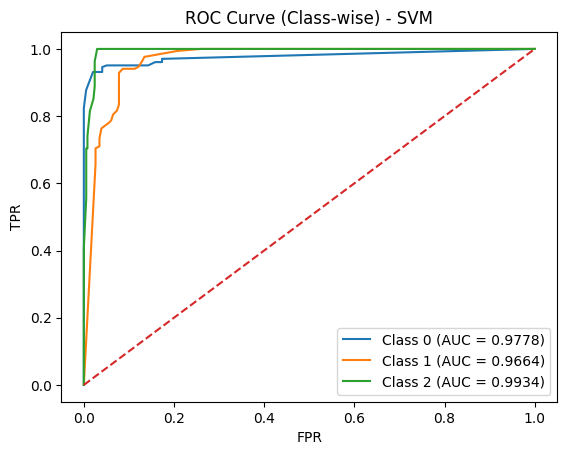

In [97]:
#############################
#  ROC CURVE (CLASS-WISE)   #
#############################

y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2])

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Class-wise) - SVM")
plt.legend()
plt.show()


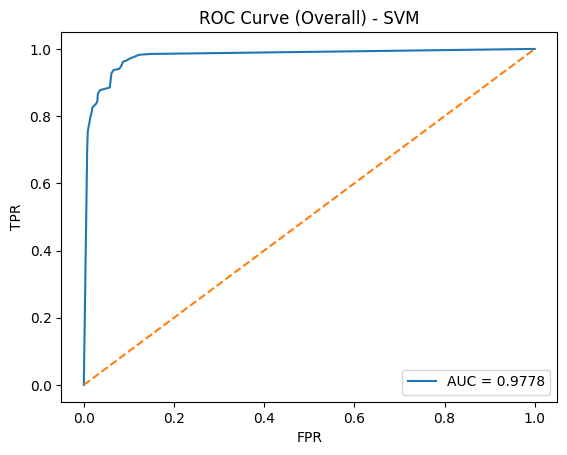

In [98]:
#############################
#    ROC CURVE (OVERALL)    #
#############################

fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), probabilities.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Overall) - SVM")
plt.legend()
plt.show()


In [99]:
#############################
#       K-FOLD SECTION      #
#############################

if RUN_KFOLD:
    X_full, y_full = preprocess_dataset(pd.read_csv(DATA_FILE))
    y_full = pd.Series(y_full).reset_index(drop=True)

    skf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full), start=1):
        print(f"\nFold {fold_idx}/{KFOLD_SPLITS}")

        X_fold_train = X_full.iloc[train_idx].reset_index(drop=True)
        y_fold_train = y_full.iloc[train_idx].reset_index(drop=True)
        X_val = X_full.iloc[val_idx].reset_index(drop=True)
        y_val = y_full.iloc[val_idx].reset_index(drop=True)

        scaler = StandardScaler()
        X_fold_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_fold_train),
            columns=X_full.columns
        )
        X_val_scaled = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_full.columns
        )

        if USE_AUGMENTATION:
            synth_n = len(X_fold_train_scaled) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES
            X_fold_train_scaled, y_fold_train = augment_training_data(
                X_fold_train_scaled,
                y_fold_train,
                n_samples=synth_n
            )

        fold_features = X_fold_train_scaled.columns

        fold_trees = []
        for _ in range(NUM_TREES):
            x_boot, y_boot = bootstrap_sample(X_fold_train_scaled, pd.Series(y_fold_train))
            fold_trees.append(construct_node(x_boot, y_boot.to_numpy(), fold_features, 0))

        y_train_pred = classify(fold_trees, X_fold_train_scaled)
        y_val_pred = classify(fold_trees, X_val_scaled)

        train_acc = np.mean(y_train_pred == y_fold_train.to_numpy())
        val_acc = np.mean(y_val_pred == y_val.to_numpy())

        from sklearn.metrics import f1_score
        val_macro_f1 = f1_score(y_val.to_numpy(), y_val_pred, average="macro", zero_division=0)

        print(f"Training Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Validation Macro F1: {val_macro_f1:.4f}")

        fold_results.append({
            "fold": fold_idx,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "val_macro_f1": val_macro_f1
        })

    fold_df = pd.DataFrame(fold_results)
    display(fold_df)

    print(f"Average Train Accuracy: {fold_df['train_accuracy'].mean():.4f}")
    print(f"Average Validation Accuracy: {fold_df['val_accuracy'].mean():.4f}")
    print(f"Average Validation Macro F1: {fold_df['val_macro_f1'].mean():.4f}")
else:
    print("RUN_KFOLD is False, so this section is skipped.")



Fold 1/5
Training Accuracy: 0.9206
Validation Accuracy: 0.9175
Validation Macro F1: 0.8468

Fold 2/5
Training Accuracy: 0.8812
Validation Accuracy: 0.8125
Validation Macro F1: 0.7613

Fold 3/5
Training Accuracy: 0.8869
Validation Accuracy: 0.8675
Validation Macro F1: 0.7966

Fold 4/5
Training Accuracy: 0.8756
Validation Accuracy: 0.8750
Validation Macro F1: 0.8374

Fold 5/5
Training Accuracy: 0.8675
Validation Accuracy: 0.8650
Validation Macro F1: 0.8122


,fold,train_accuracy,val_accuracy,val_macro_f1
0,1,0.920625,0.9175,0.846754
1,2,0.881250,0.8125,0.761292
2,3,0.886875,0.8675,0.796619
3,4,0.875625,0.8750,0.837425
4,5,0.867500,0.8650,0.812183


Average Train Accuracy: 0.8864
Average Validation Accuracy: 0.8675
Average Validation Macro F1: 0.8109
